In [1]:
level_depth=0
level_depth1=1

In [2]:
from IPython.display import display
import os
import numpy as np
import pandas as pd

import plotly.express as px  # per il grafico lineare
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [3]:
#STRATEGY 1

'''
Tables in DB: [('chats',)]
number of unique chats 127141
chats.db - Tabella 'chats'
           type_and_id                   token                  parent  \
0                 None  [keyword] thedemocrats                    None   
40  channel_1889806290         thedemocratskmf  [keyword] thedemocrats   
41  channel_1413288788       thedemocratsindia  [keyword] thedemocrats      

       timestamp  
0   1.722583e+09  
40  1.728093e+09  
41  1.728093e+09  

✅ discovery_edges.csv.gz, 
Il timestamp da l'ultima volta che hanno visitato quel gruppo ma questo significa che non è davvero indicativo di una timeline 

          type_and_id              parent     timestamp
0  channel_1306559115  channel_1840578235  1.722586e+09
1  channel_2036850729  channel_1840578235  1.722586e+09
2  channel_1941222046  channel_1840578235  1.722586e+09

number of non unique first nodes 284
✅ first_nodes.csv.gz
          type_and_id                    token                      parent
0  channel_2036421633               trump2024e         [keyword] Trump2024
1  channel_2178554925  biden_has_left_the_chat             [keyword] Biden
2  channel_2095394414             speech_biden      [keyword] Joseph Biden

number of unique first nodes 247
'''

#paths
path_summary_filtered_0 = f"../results/levels/level_{level_depth}/percentage_of_politics_msgs/summary_pol_sorted_filtered_spam.csv.gz"
path_summary_filtered_1 = f"../results/levels/level_{level_depth1}/percentage_of_politics_msgs/summary_pol_sorted_filtered_spam.csv.gz"
path_df_edges = f"../material/discovery_edges.csv.gz"

# load summary with pol_ratio_without_spam for every channel_id
summary_filtered0  = pd.read_csv(path_summary_filtered_0, compression="gzip")
summary_filtered1  = pd.read_csv(path_summary_filtered_1, compression="gzip")
summary_filtered = pd.concat([summary_filtered0, summary_filtered1], ignore_index=True)
summary_filtered = summary_filtered.drop_duplicates(subset='channel_id', keep='last')

print(f"len summary_filtered = {len(summary_filtered)}")
print(f"summary_filtered:\n {summary_filtered.head()}")

# load discovery_edges
df_edges = pd.read_csv(path_df_edges, compression="gzip")
print(f"df_edges:\n {df_edges.head()}")

#filter for only the istances of channels in summary_filtered
children = df_edges[df_edges['parent'].isin(summary_filtered['channel_id'])].reset_index(drop=True)

#extract the unique istances of type_and_id
df_unique_children = children[['type_and_id']].drop_duplicates().reset_index(drop=True)

#save
print(f"lenght of df_unique_childen {len(df_unique_children)}")





len summary_filtered = 233
summary_filtered:
            channel_id  total_msgs_without_spam  pol_msgs  economy_msgs  \
0  channel_1076871110                      555       211            20   
1  channel_1245638927                      914       403            26   
2  channel_1269157403                      142        36             3   
3  channel_1283801046                       19         7             0   
4  channel_1292024994                       78        41             2   

   crypto_msgs  not_categorized_msgs  spam_msgs  outliers_msgs  \
0           18                    93      28273            213   
1           77                   180        520            228   
2            1                    74          0             28   
3            0                     6          0              6   
4            2                     6          0             27   

   total_msgs_with_spam  pol_ratio_without_spam  economy_ratio_without_spam  \
0                 28828          

len summary_filtered: 233
len parents_df: 233
len parent_edges_df: 24333
len children_df: 194


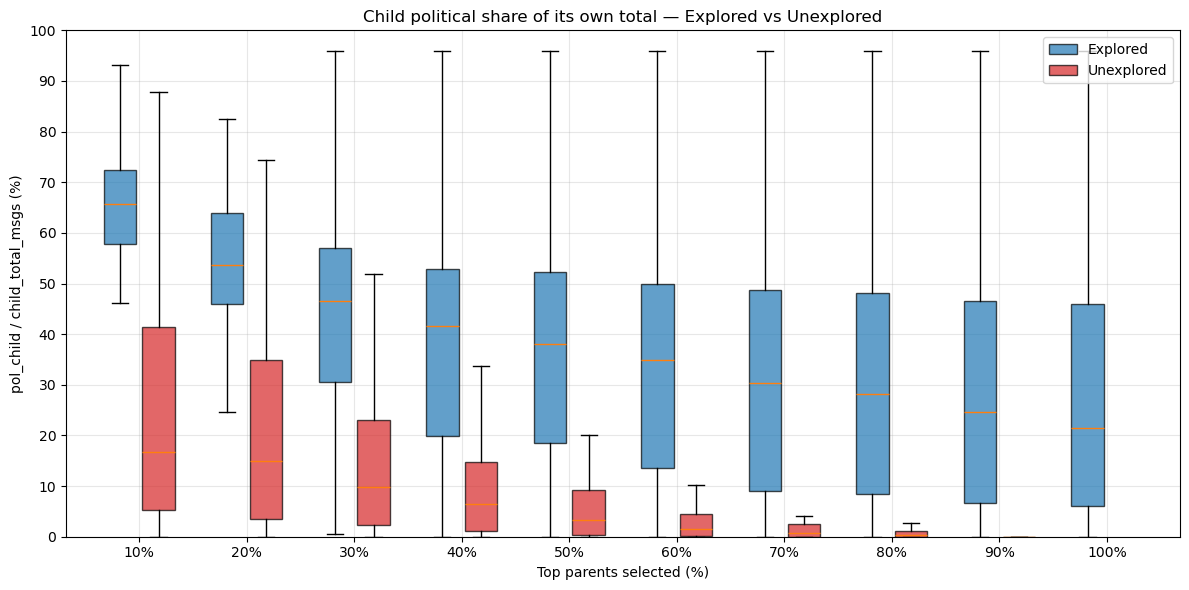

M3 medians (Explored vs Unexplored):
  Top_%  Explored_med%  Unexplored_med%
    10      65.800866        16.666667
    20      53.690603        14.922559
    30      46.590909         9.797297
    40      41.608402         6.486486
    50      38.018018         3.225806
    60      34.854799         1.586437
    70      30.424528         0.743494
    80      28.282956         0.331561
    90      24.677049         0.000000
   100      21.434379              NaN

Counts per fraction (Explored vs Unexplored):
  top_parents_pct  explored_count  unexplored_count  total_children
              10              21               173             194
              20              44               150             194
              30              85               109             194
              40             116                78             194
              50             135                59             194
              60             154                40             194
              70

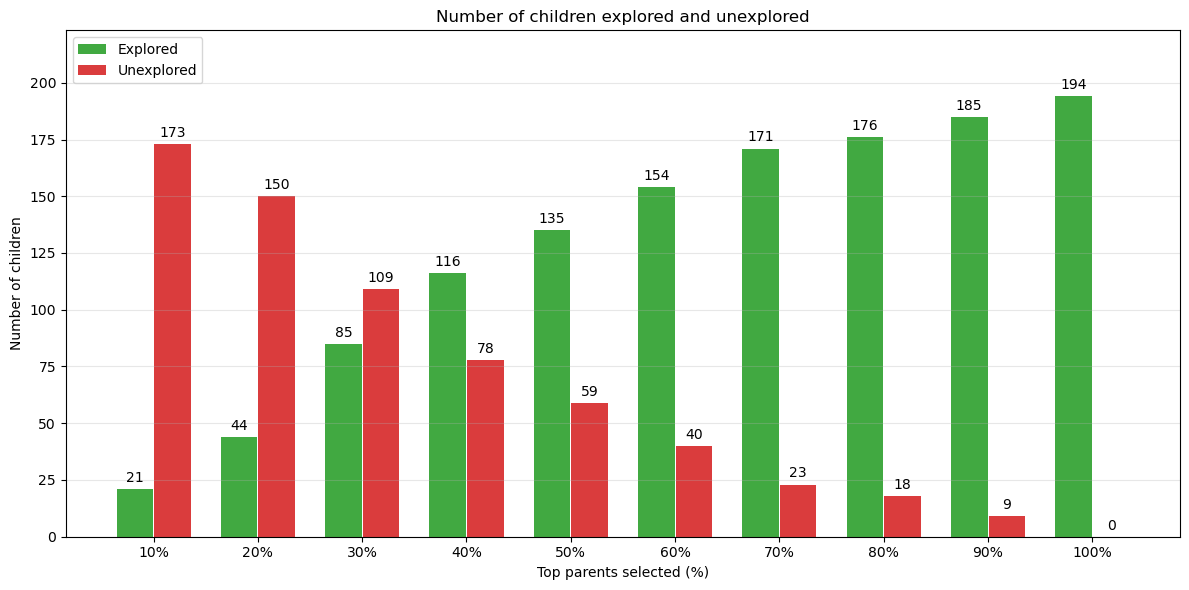

In [14]:
# ============================
# Setup e dati (già caricati da te)
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ATTENZIONE: allineo i tipi numerici
summary_filtered0  = pd.read_csv(path_summary_filtered_0, compression="gzip")
summary_filtered1  = pd.read_csv(path_summary_filtered_1, compression="gzip")
summary_filtered = pd.concat([summary_filtered0, summary_filtered1], ignore_index=True)

# dedup sul vero ID di canale (stringa 'channel_...'), tieni l'ultima
summary_filtered = (summary_filtered
    .drop_duplicates(subset='channel_id', keep='last')
    .copy())

# cast numerici robusti
summary_filtered['pol_ratio_without_spam']  = pd.to_numeric(summary_filtered['pol_ratio_without_spam'], errors='coerce')
summary_filtered['pol_msgs']                = pd.to_numeric(summary_filtered['pol_msgs'], errors='coerce')
summary_filtered['total_msgs_without_spam'] = pd.to_numeric(summary_filtered['total_msgs_without_spam'], errors='coerce')

# edges grezzi
df_edges = pd.read_csv(path_df_edges, compression="gzip")

print(f"len summary_filtered: {len(summary_filtered)}")

# ============================
# 1) Parents ranking (eleggibili = con share non-NaN)
# ============================
parents_df = (summary_filtered[['channel_id', 'pol_ratio_without_spam']]
              .rename(columns={'channel_id':'parent_id',
                               'pol_ratio_without_spam':'parent_political_share'})
              .dropna(subset=['parent_id','parent_political_share'])
              .drop_duplicates(subset='parent_id')
              .copy())
parents_df['parent_political_share'] = parents_df['parent_political_share'].astype(float)

print(f"len parents_df: {len(parents_df)}")

# ============================
# 2) Edges solo verso genitori eleggibili
# ============================
parent_edges_df = (df_edges[df_edges['parent'].isin(parents_df['parent_id'])]
                   [['parent','type_and_id']]
                   .rename(columns={'parent':'parent_id','type_and_id':'child_id'})
                   .dropna()
                   .drop_duplicates()
                   .reset_index(drop=True))

print(f"len parent_edges_df: {len(parent_edges_df)}")

# ============================
# 3) Children stats (solo figli che hanno metriche)
# ============================
children_stats = (summary_filtered
                  .rename(columns={'channel_id':'child_id',
                                   'pol_msgs':'political_msgs',
                                   'total_msgs_without_spam':'total_msgs'})
                  [['child_id','political_msgs','total_msgs']])

children_df = (pd.merge(parent_edges_df[['child_id']].drop_duplicates(),
                        children_stats, on='child_id', how='left')
               .dropna(subset=['political_msgs','total_msgs'])
               .copy())
children_df['political_msgs'] = children_df['political_msgs'].astype(float)
children_df['total_msgs']     = children_df['total_msgs'].astype(float)
children_df = children_df[children_df['total_msgs'] > 0].reset_index(drop=True)

print(f"len children_df: {len(children_df)}")

# ============================
# Helpers
# ============================
def order_parents(parents_df: pd.DataFrame) -> np.ndarray:
    """Ordina i genitori per share politico desc e restituisce gli ID."""
    ordered = (parents_df
               .dropna(subset=['parent_political_share'])
               .sort_values('parent_political_share', ascending=False)['parent_id']
               .to_numpy())
    if len(ordered) == 0:
        raise ValueError("No parents available after sorting.")
    return ordered

# ============================
# 4) M3: boxplot Explored vs Unexplored (stesso universo dei figli con stats)
# ============================
def compute_m3_both_groups(parents_df, parent_edges_df, children_df,
                           total_col='total_msgs',
                           top_parent_percents=list(range(10, 101, 10))) -> pd.DataFrame:
    """
    Ritorna DF con: [metric, top_parents_pct, child_id, value_pct, Group]
    Group ∈ {'Explored','Unexplored'}
    Universo figli = SOLO quelli con stats (children_df).
    """
    child_lookup = (children_df[['child_id','political_msgs', total_col]]
                    .drop_duplicates().set_index('child_id'))

    elig_children_in_edges = np.unique(parent_edges_df['child_id'].dropna().to_numpy())
    universe_children = np.intersect1d(elig_children_in_edges, child_lookup.index.to_numpy(), assume_unique=False)

    ordered = order_parents(parents_df)
    n_parents = len(ordered)

    rows = []
    for perc in sorted(top_parent_percents):
        k = max(1, int(np.ceil(n_parents * (perc/100.0))))
        topk = set(ordered[:k])

        sel = parent_edges_df['parent_id'].isin(topk)
        explored_children = np.unique(parent_edges_df.loc[sel, 'child_id'].dropna().to_numpy())

        explored_children = np.intersect1d(universe_children, explored_children, assume_unique=False)
        unexplored_children = np.setdiff1d(universe_children, explored_children, assume_unique=False)

        # Explored
        if explored_children.size:
            sub_e = child_lookup.reindex(explored_children)[['political_msgs', total_col]].dropna()
            sub_e = sub_e[sub_e[total_col] > 0]
            vals_e = (sub_e['political_msgs'] / sub_e[total_col]) * 100.0
            rows += [{'metric': f'M3_over_{total_col}', 'top_parents_pct': int(perc),
                      'child_id': int(cid) if str(cid).isdigit() else cid,
                      'value_pct': float(v), 'Group': 'Explored'}
                     for cid, v in zip(sub_e.index, vals_e.to_numpy())]

        # Unexplored
        if unexplored_children.size:
            sub_u = child_lookup.reindex(unexplored_children)[['political_msgs', total_col]].dropna()
            sub_u = sub_u[sub_u[total_col] > 0]
            vals_u = (sub_u['political_msgs'] / sub_u[total_col]) * 100.0
            rows += [{'metric': f'M3_over_{total_col}', 'top_parents_pct': int(perc),
                      'child_id': int(cid) if str(cid).isdigit() else cid,
                      'value_pct': float(v), 'Group': 'Unexplored'}
                     for cid, v in zip(sub_u.index, vals_u.to_numpy())]

    return pd.DataFrame(rows)

def make_grouped_boxplot(df: pd.DataFrame, title: str, y_label: str, save_name: str = None):
    """Boxplot affiancati Explored vs Unexplored con stile matplotlib uniforme."""
    if df.empty:
        print(f"[WARN] Empty dataframe for plot: {title}")
        return

    fracs = sorted(df['top_parents_pct'].unique())
    positions_base = list(range(len(fracs)))

    fig, ax = plt.subplots(figsize=(12, 6))

    box_width = 0.3
    offset = 0.18

    # Boxplot Explored (sinistra)
    explored_data = [
        df.loc[(df['top_parents_pct'] == f) & (df['Group'] == 'Explored'), 'value_pct'].values
        for f in fracs
    ]
    bp1 = ax.boxplot(
        explored_data, positions=[p - offset for p in positions_base],
        widths=box_width, patch_artist=True, showfliers=False
    )
    for box in bp1['boxes']:
        box.set_facecolor('#1f77b4')
        box.set_alpha(0.7)

    # Boxplot Unexplored (destra)
    unexplored_data = [
        df.loc[(df['top_parents_pct'] == f) & (df['Group'] == 'Unexplored'), 'value_pct'].values
        for f in fracs
    ]
    bp2 = ax.boxplot(
        unexplored_data, positions=[p + offset for p in positions_base],
        widths=box_width, patch_artist=True, showfliers=False
    )
    for box in bp2['boxes']:
        box.set_facecolor('#d62728')
        box.set_alpha(0.7)

    ax.set_xticks(positions_base)
    ax.set_xticklabels([f'{int(f)}%' for f in fracs])
    ax.set_yticks(range(0, 101, 10))
    ax.set_ylim(0, 100)
    ax.set_xlabel('Top parents selected (%)')
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Explored', 'Unexplored'])
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_name:
        plt.savefig(f'{save_name}.png', dpi=150, bbox_inches='tight')
        plt.savefig(f'{save_name}.pdf', bbox_inches='tight')
    plt.show()

def quick_medians_by_group(df):
    return (df.groupby(['top_parents_pct','Group'])['value_pct']
              .median().reset_index()
              .pivot(index='top_parents_pct', columns='Group', values='value_pct')
              .rename_axis(None, axis=1)
              .reset_index()
              .rename(columns={'top_parents_pct':'Top_%', 'Explored':'Explored_med%', 'Unexplored':'Unexplored_med%'}))

# ============================
# 5) Counts coerenti con M3 (stesso universo figli con stats)
# ============================
def compute_child_counts(parents_df, parent_edges_df, children_df,
                         top_parent_percents=list(range(10, 101, 10))) -> pd.DataFrame:
    """
    Conta figli Explored/Unexplored usando ESATTAMENTE l'universo di children_df.
    A 100%: explored == total_children, unexplored == 0.
    """
    ordered = order_parents(parents_df)
    n_parents = len(ordered)

    elig_children_in_edges = np.unique(parent_edges_df['child_id'].dropna().to_numpy())
    universe_children = np.intersect1d(elig_children_in_edges,
                                       children_df['child_id'].dropna().unique(),
                                       assume_unique=False)
    total_children = int(universe_children.size)

    rows = []
    for perc in sorted(top_parent_percents):
        k = max(1, int(np.ceil(n_parents * (perc/100.0))))
        topk = set(ordered[:k])

        sel = parent_edges_df['parent_id'].isin(topk)
        explored_children = np.unique(parent_edges_df.loc[sel, 'child_id'].dropna().to_numpy())
        explored_children = np.intersect1d(universe_children, explored_children, assume_unique=False)
        unexplored_children = np.setdiff1d(universe_children, explored_children, assume_unique=False)

        rows.append({
            'top_parents_pct': int(perc),
            'explored_count' : int(explored_children.size),
            'unexplored_count': int(unexplored_children.size),
            'total_children'  : total_children
        })

    counts_df = pd.DataFrame(rows)
    bad = counts_df[(counts_df['explored_count'] + counts_df['unexplored_count']) != counts_df['total_children']]
    if not bad.empty:
        print("[WARN] Some rows do not sum to total_children:\n", bad)
    return counts_df

def make_counts_plot(counts_df: pd.DataFrame, total_note: str = "", save_name: str = None):
    """Barre affiancate con stile uniforme e salvataggio PDF."""
    if counts_df.empty:
        print("[WARN] Empty counts_df; nothing to plot.")
        return

    fracs = counts_df['top_parents_pct'].astype(int).tolist()
    explored = counts_df['explored_count'].to_numpy()
    unexplored = counts_df['unexplored_count'].to_numpy()

    positions_base = list(range(len(fracs)))

    fig, ax = plt.subplots(figsize=(12, 6))

    box_width = 0.35
    offset = 0.18

    bars_expl = ax.bar(
        [p - offset for p in positions_base], explored,
        width=box_width, color='#2ca02c', alpha=0.9, label='Explored'
    )
    bars_unex = ax.bar(
        [p + offset for p in positions_base], unexplored,
        width=box_width, color='#d62728', alpha=0.9, label='Unexplored'
    )

    ax.bar_label(bars_expl, labels=[str(int(v)) for v in explored], padding=3, fontsize=10)
    ax.bar_label(bars_unex, labels=[str(int(v)) for v in unexplored], padding=3, fontsize=10)

    ax.set_xticks(positions_base)
    ax.set_xticklabels([f'{f}%' for f in fracs])
    ax.set_xlabel('Top parents selected (%)')
    ax.set_ylabel('Number of children')
    ttl = 'Number of children explored and unexplored'
    if total_note:
        ttl += f'  {total_note}'
    ax.set_title(ttl)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    ymax = max(explored.max() if explored.size else 0,
               unexplored.max() if unexplored.size else 0)
    ax.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)

    plt.tight_layout()
    if save_name:
        plt.savefig(f'{save_name}.png', dpi=150, bbox_inches='tight')
        plt.savefig(f'{save_name}.pdf', bbox_inches='tight')
    plt.show()

# ============================
# 6) Run: M3 + medians + counts coerenti
# ============================
fractions = list(range(10, 101, 10))

m3_both = compute_m3_both_groups(
    parents_df, parent_edges_df, children_df,
    total_col='total_msgs',
    top_parent_percents=fractions
)

make_grouped_boxplot(
    m3_both,
    "Child political share of its own total — Explored vs Unexplored",
    "pol_child / child_total_msgs (%)",
    save_name="pol_ratio_boxplot_cumulative"
)

med = quick_medians_by_group(m3_both)
print("M3 medians (Explored vs Unexplored):\n", med.to_string(index=False))

counts_df = compute_child_counts(parents_df, parent_edges_df, children_df,
                                 top_parent_percents=fractions)
print("\nCounts per fraction (Explored vs Unexplored):\n", counts_df.to_string(index=False))

make_counts_plot(
    counts_df,
    total_note=f"",
    save_name="children_explored"
)

len summary_filtered: 233
len parents_df: 233
len parent_edges_df: 24333
len children_df: 194


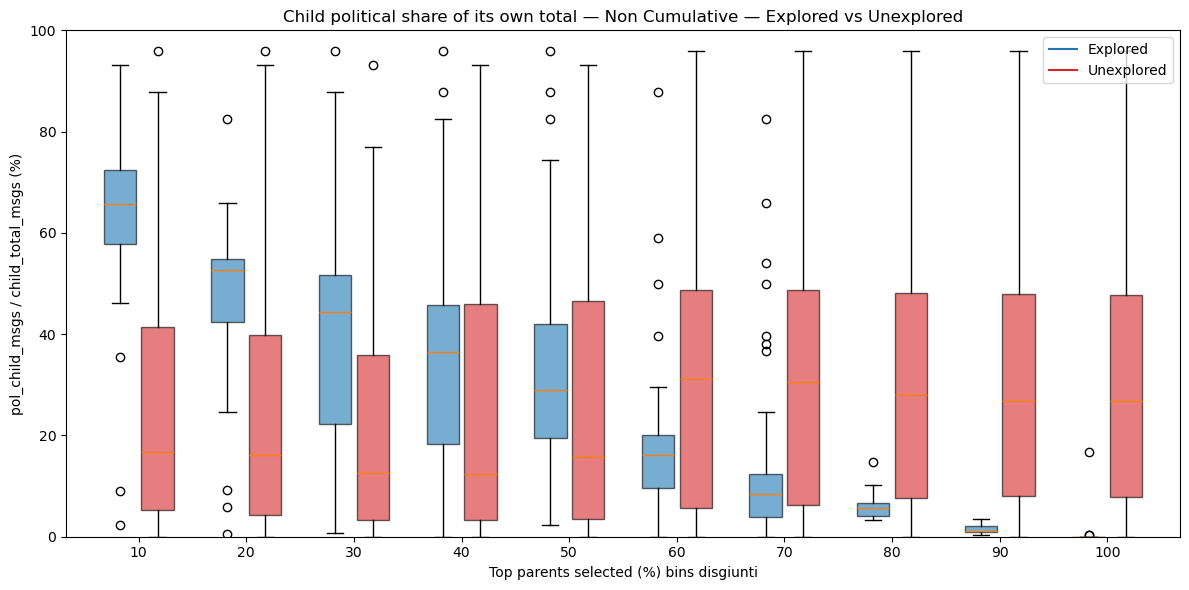

M3 medians (Explored vs Unexplored):
  Top_%  Explored_med%  Unexplored_med%
    10      65.800866        16.666667
    20      52.640551        16.201117
    30      44.444444        12.500000
    40      36.568627        12.293807
    50      29.023668        15.718672
    60      16.201117        31.068296
    70       8.415033        30.503101
    80       5.578231        28.037383
    90       1.219512        26.900585
   100       0.000000        26.783626

Counts per fraction (Explored vs Unexplored):
  top_parents_pct  explored_count  unexplored_count  total_children
              10              21               173             194
              20              44               150             194
              30              85               109             194
              40             116                78             194
              50             135                59             194
              60             154                40             194
              70

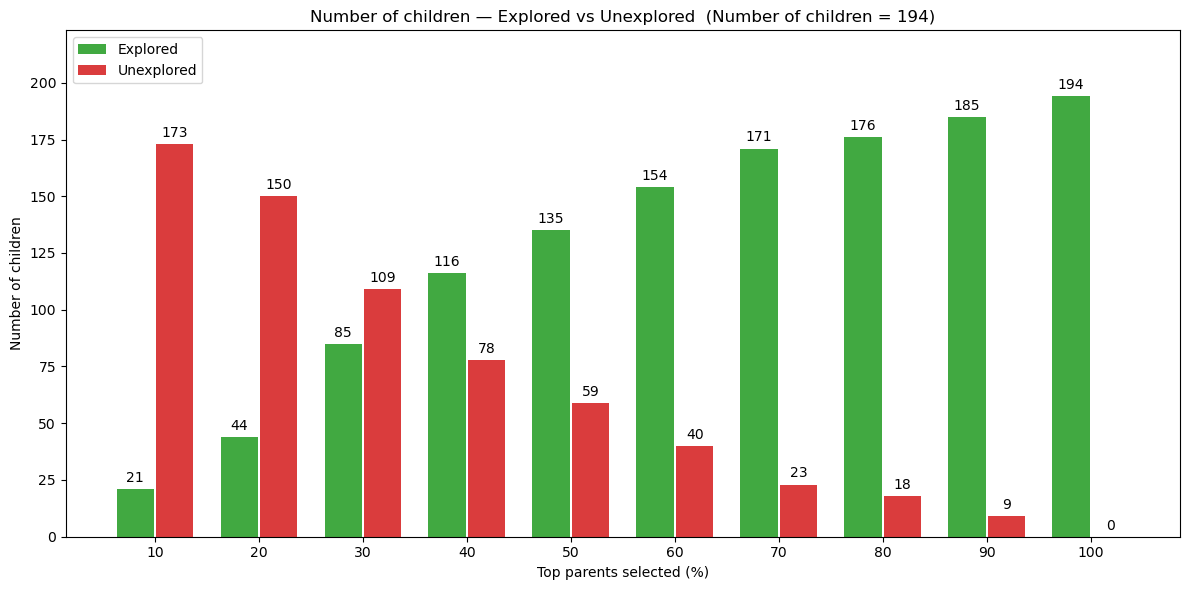

In [5]:
# ============================
# Setup e dati (già caricati da te)
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ATTENZIONE: allineo i tipi numerici
summary_filtered0  = pd.read_csv(path_summary_filtered_0, compression="gzip")
summary_filtered1  = pd.read_csv(path_summary_filtered_1, compression="gzip")
summary_filtered = pd.concat([summary_filtered0, summary_filtered1], ignore_index=True)

# dedup sul vero ID di canale (stringa 'channel_...'), tieni l'ultima
summary_filtered = (summary_filtered
    .drop_duplicates(subset='channel_id', keep='last')
    .copy())

# cast numerici robusti
summary_filtered['pol_ratio_without_spam']  = pd.to_numeric(summary_filtered['pol_ratio_without_spam'], errors='coerce')
summary_filtered['pol_msgs']                = pd.to_numeric(summary_filtered['pol_msgs'], errors='coerce')
summary_filtered['total_msgs_without_spam'] = pd.to_numeric(summary_filtered['total_msgs_without_spam'], errors='coerce')

# edges grezzi
df_edges = pd.read_csv(path_df_edges, compression="gzip")

print(f"len summary_filtered: {len(summary_filtered)}")

# ============================
# 1) Parents ranking (eleggibili = con share non-NaN)
# ============================
parents_df = (summary_filtered[['channel_id', 'pol_ratio_without_spam']]
              .rename(columns={'channel_id':'parent_id',
                               'pol_ratio_without_spam':'parent_political_share'})
              .dropna(subset=['parent_id','parent_political_share'])
              .drop_duplicates(subset='parent_id')
              .copy())
parents_df['parent_political_share'] = parents_df['parent_political_share'].astype(float)

print(f"len parents_df: {len(parents_df)}")

# ============================
# 2) Edges solo verso genitori eleggibili
# ============================
parent_edges_df = (df_edges[df_edges['parent'].isin(parents_df['parent_id'])]
                   [['parent','type_and_id']]
                   .rename(columns={'parent':'parent_id','type_and_id':'child_id'})
                   .dropna()
                   .drop_duplicates()
                   .reset_index(drop=True))

print(f"len parent_edges_df: {len(parent_edges_df)}")

# ============================
# 3) Children stats (solo figli che hanno metriche)
# ============================
children_stats = (summary_filtered
                  .rename(columns={'channel_id':'child_id',
                                   'pol_msgs':'political_msgs',
                                   'total_msgs_without_spam':'total_msgs'})
                  [['child_id','political_msgs','total_msgs']])

children_df = (pd.merge(parent_edges_df[['child_id']].drop_duplicates(),
                        children_stats, on='child_id', how='left')
               .dropna(subset=['political_msgs','total_msgs'])
               .copy())
children_df['political_msgs'] = children_df['political_msgs'].astype(float)
children_df['total_msgs']     = children_df['total_msgs'].astype(float)
children_df = children_df[children_df['total_msgs'] > 0].reset_index(drop=True)

print(f"len children_df: {len(children_df)}")  # <- questo è l'universo usato in ENTRAMBI i grafici

# ============================
# Helpers
# ============================
def order_parents(parents_df: pd.DataFrame) -> np.ndarray:
    """Ordina i genitori per share politico desc e restituisce gli ID."""
    ordered = (parents_df
               .dropna(subset=['parent_political_share'])
               .sort_values('parent_political_share', ascending=False)['parent_id']
               .to_numpy())
    if len(ordered) == 0:
        raise ValueError("No parents available after sorting.")
    return ordered

# ============================
# 4) M3: boxplot Explored vs Unexplored (SOLO QUI disgiunto)
# ============================
def compute_m3_both_groups(parents_df, parent_edges_df, children_df,
                           total_col='total_msgs',
                           top_parent_percents=list(range(10, 101, 10)),
                           cumulative=False) -> pd.DataFrame:
    """
    Ritorna DF con: [metric, top_parents_pct, child_id, value_pct, Group]
    Group ∈ {'Explored','Unexplored'}
    Universo figli = SOLO quelli con stats (children_df).

    cumulative=True  -> top-k cumulativo (10%=top10, 20%=top20 include top10, ...)
    cumulative=False -> bin disgiunti: [0-10), [10-20), ..., [90-100)
    """
    # lookup solo su figli con stats
    child_lookup = (children_df[['child_id','political_msgs', total_col]]
                    .drop_duplicates().set_index('child_id'))

    # universo coerente: figli con stats che compaiono in edges (genitori eleggibili)
    elig_children_in_edges = np.unique(parent_edges_df['child_id'].dropna().to_numpy())
    universe_children = np.intersect1d(elig_children_in_edges, child_lookup.index.to_numpy(), assume_unique=False)

    ordered = order_parents(parents_df)
    n_parents = len(ordered)

    rows = []
    prev_pct = 0
    for perc in sorted(top_parent_percents):
        if cumulative:
            k = max(1, int(np.ceil(n_parents * (perc/100.0))))
            sel_parents = ordered[:k]
        else:
            start = int(np.floor(n_parents * (prev_pct/100.0)))
            end   = int(np.ceil (n_parents * (perc/100.0)))
            if end <= start:
                end = min(n_parents, start + 1)  # >=1 parent se possibile
            sel_parents = ordered[start:end]

        prev_pct = perc

        # figli explored/unexplored relativi SOLO al set selezionato
        sel = parent_edges_df['parent_id'].isin(set(sel_parents))
        explored_children = np.unique(parent_edges_df.loc[sel, 'child_id'].dropna().to_numpy())

        # allinea all'universo
        explored_children = np.intersect1d(universe_children, explored_children, assume_unique=False)
        unexplored_children = np.setdiff1d(universe_children, explored_children, assume_unique=False)

        # Explored
        if explored_children.size:
            sub_e = child_lookup.reindex(explored_children)[['political_msgs', total_col]].dropna()
            sub_e = sub_e[sub_e[total_col] > 0]
            vals_e = (sub_e['political_msgs'] / sub_e[total_col]) * 100.0
            rows += [{'metric': f'M3_over_{total_col}', 'top_parents_pct': int(perc),
                      'child_id': int(cid) if str(cid).isdigit() else cid,
                      'value_pct': float(v), 'Group': 'Explored'}
                     for cid, v in zip(sub_e.index, vals_e.to_numpy())]

        # Unexplored
        if unexplored_children.size:
            sub_u = child_lookup.reindex(unexplored_children)[['political_msgs', total_col]].dropna()
            sub_u = sub_u[sub_u[total_col] > 0]
            vals_u = (sub_u['political_msgs'] / sub_u[total_col]) * 100.0
            rows += [{'metric': f'M3_over_{total_col}', 'top_parents_pct': int(perc),
                      'child_id': int(cid) if str(cid).isdigit() else cid,
                      'value_pct': float(v), 'Group': 'Unexplored'}
                     for cid, v in zip(sub_u.index, vals_u.to_numpy())]

    return pd.DataFrame(rows)

def make_grouped_boxplot(df: pd.DataFrame, title: str, y_label: str):
    """Boxplot affiancati Explored vs Unexplored per ogni percentuale (o bin) di top parents."""
    if df.empty:
        print(f"[WARN] Empty dataframe for plot: {title}")
        return

    fracs = sorted(df['top_parents_pct'].unique())
    groups = ['Explored', 'Unexplored']

    data_by_group = {g: [] for g in groups}
    for f in fracs:
        for g in groups:
            vals = df.loc[(df['top_parents_pct'] == f) & (df['Group'] == g), 'value_pct'].to_numpy()
            data_by_group[g].append(vals)

    x = np.arange(len(fracs))
    width = 0.35
    pos_expl = x - width/2
    pos_unex = x + width/2

    fig, ax = plt.subplots(figsize=(12, 6))
    bp1 = ax.boxplot(data_by_group['Explored'], positions=pos_expl, widths=0.3, patch_artist=True, showfliers=True)
    bp2 = ax.boxplot(data_by_group['Unexplored'], positions=pos_unex, widths=0.3, patch_artist=True, showfliers=True)

    for patch in bp1['boxes']:
        patch.set_facecolor('#1f77b4'); patch.set_alpha(0.6)
    for patch in bp2['boxes']:
        patch.set_facecolor('#d62728'); patch.set_alpha(0.6)

    ax.set_xticks(x); ax.set_xticklabels([str(int(f)) for f in fracs])
    ax.set_xlabel("Top parents selected (%) bins disgiunti")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.plot([], [], color='#1f77b4', label='Explored')
    ax.plot([], [], color='#d62728', label='Unexplored')
    ax.legend()
    ax.set_ylim(0, 100)
    fig.tight_layout()
    plt.show()

def quick_medians_by_group(df):
    return (df.groupby(['top_parents_pct','Group'])['value_pct']
              .median().reset_index()
              .pivot(index='top_parents_pct', columns='Group', values='value_pct')
              .rename_axis(None, axis=1)
              .reset_index()
              .rename(columns={'top_parents_pct':'Top_%', 'Explored':'Explored_med%', 'Unexplored':'Unexplored_med%'}))

# ============================
# 5) Counts coerenti con M3 (IDENTICO e CUMULATIVO)
# ============================
def compute_child_counts(parents_df, parent_edges_df, children_df,
                         top_parent_percents=list(range(10, 101, 10))) -> pd.DataFrame:
    """
    Conta figli Explored/Unexplored usando ESATTAMENTE l'universo di children_df.
    CUMULATIVO: a 100% -> explored == total_children, unexplored == 0.
    """
    ordered = order_parents(parents_df)
    n_parents = len(ordered)

    elig_children_in_edges = np.unique(parent_edges_df['child_id'].dropna().to_numpy())
    universe_children = np.intersect1d(elig_children_in_edges,
                                       children_df['child_id'].dropna().unique(),
                                       assume_unique=False)
    total_children = int(universe_children.size)

    rows = []
    for perc in sorted(top_parent_percents):
        k = max(1, int(np.ceil(n_parents * (perc/100.0))))
        topk = set(ordered[:k])

        sel = parent_edges_df['parent_id'].isin(topk)
        explored_children = np.unique(parent_edges_df.loc[sel, 'child_id'].dropna().to_numpy())
        explored_children = np.intersect1d(universe_children, explored_children, assume_unique=False)
        unexplored_children = np.setdiff1d(universe_children, explored_children, assume_unique=False)

        rows.append({
            'top_parents_pct': int(perc),
            'explored_count' : int(explored_children.size),
            'unexplored_count': int(unexplored_children.size),
            'total_children'  : total_children
        })

    counts_df = pd.DataFrame(rows)
    bad = counts_df[(counts_df['explored_count'] + counts_df['unexplored_count']) != counts_df['total_children']]
    if not bad.empty:
        print("[WARN] Some rows do not sum to total_children:\n", bad)
    return counts_df

def make_counts_plot(counts_df: pd.DataFrame, total_note: str = ""):
    """Barre affiancate con valore su ogni barra; niente etichette 'Total children' ripetute."""
    if counts_df.empty:
        print("[WARN] Empty counts_df; nothing to plot.")
        return

    fracs = counts_df['top_parents_pct'].astype(int).tolist()
    explored = counts_df['explored_count'].to_numpy()
    unexplored = counts_df['unexplored_count'].to_numpy()

    x = np.arange(len(fracs))
    width = 0.38
    pos_expl = x - width/2
    pos_unex = x + width/2

    fig, ax = plt.subplots(figsize=(12, 6))
    # — colori: verde per Explored, rosso per Unexplored
    bars_expl = ax.bar(pos_expl, explored,   width=0.36, color='#2ca02c', alpha=0.90, label='Explored')
    bars_unex = ax.bar(pos_unex, unexplored, width=0.36, color='#d62728', alpha=0.90, label='Unexplored')

    ax.set_xticks(x); ax.set_xticklabels([str(f) for f in fracs])
    ax.set_xlabel("Top parents selected (%)")
    ax.set_ylabel("Number of children")
    ttl = "Number of children — Explored vs Unexplored"
    if total_note: ttl += f"  ({total_note})"
    ax.set_title(ttl)
    ax.legend()

    # --- Etichette numeriche su OGNI barra ---
    ax.bar_label(bars_expl, labels=[str(int(v)) for v in explored], padding=3, fontsize=10)
    ax.bar_label(bars_unex, labels=[str(int(v)) for v in unexplored], padding=3, fontsize=10)

    # margine alto per non tagliare le etichette
    ymax = max(explored.max() if explored.size else 0,
               unexplored.max() if unexplored.size else 0)
    ax.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)

    fig.tight_layout()
    plt.show()

# ============================
# 6) Run: M3 (disgiunto) + medians + counts (cumulativo) coerenti
# ============================
fractions = list(range(10, 101, 10))

# Boxplot: BIN DISGIUNTI
m3_both = compute_m3_both_groups(
    parents_df, parent_edges_df, children_df,
    total_col='total_msgs',
    top_parent_percents=fractions,
    cumulative=False  # ⬅️ solo il boxplot è disgiunto
)

make_grouped_boxplot(
    m3_both,
    "Child political share of its own total — Non Cumulative — Explored vs Unexplored",
    "pol_child_msgs / child_total_msgs (%)"
)

med = quick_medians_by_group(m3_both)
print("M3 medians (Explored vs Unexplored):\n", med.to_string(index=False))

# BARS: IDENTICO (CUMULATIVO)
counts_df = compute_child_counts(
    parents_df, parent_edges_df, children_df,
    top_parent_percents=fractions
)
print("\nCounts per fraction (Explored vs Unexplored):\n", counts_df.to_string(index=False))

make_counts_plot(
    counts_df,
    total_note=f"Number of children = {counts_df['total_children'].iloc[0]}"
)


len summary_filtered: 233
len parents_df: 233
len parent_edges_df: 24333
len children_df: 194


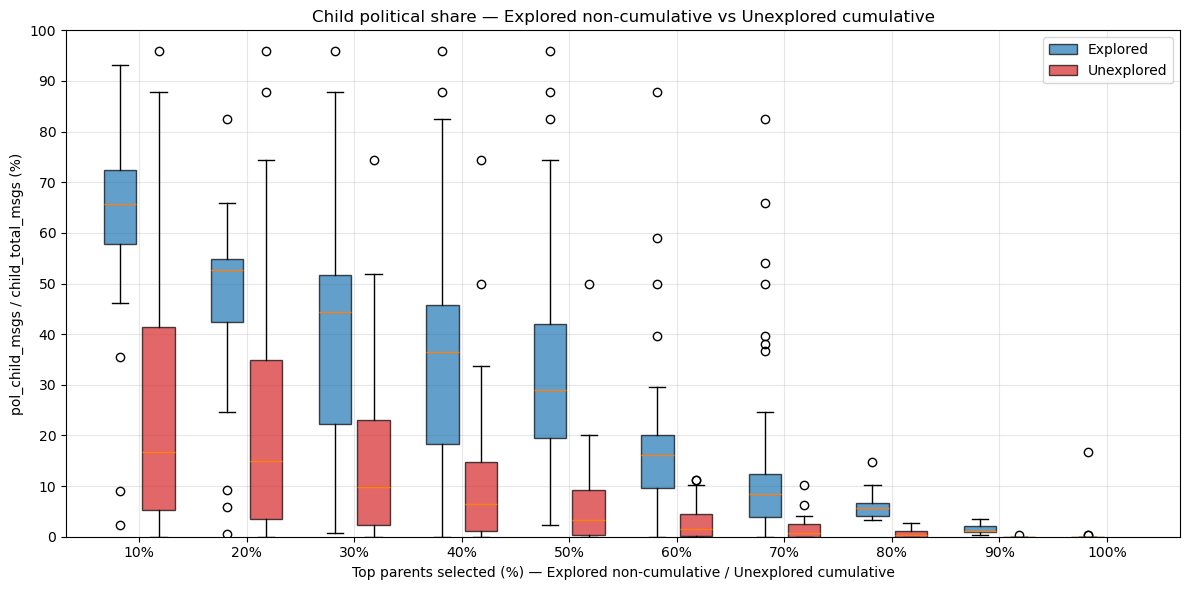

M3 medians (Explored vs Unexplored):
  Top_%  Explored_med%  Unexplored_med%
    10      65.800866        16.666667
    20      52.640551        14.922559
    30      44.444444         9.797297
    40      36.568627         6.486486
    50      29.023668         3.225806
    60      16.201117         1.586437
    70       8.415033         0.743494
    80       5.578231         0.331561
    90       1.219512         0.000000
   100       0.000000              NaN

Counts per fraction (Explored vs Unexplored):
  top_parents_pct  explored_count  unexplored_count  total_children
              10              21               173             194
              20              44               150             194
              30              85               109             194
              40             116                78             194
              50             135                59             194
              60             154                40             194
              70

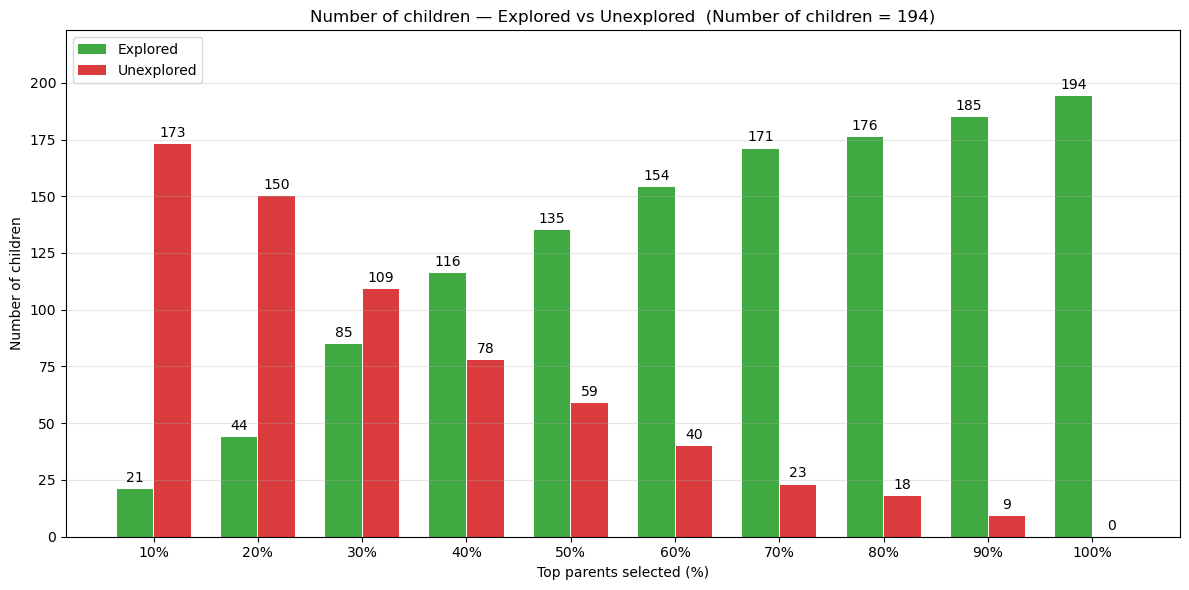

len summary_filtered: 233
len parents_df: 233
len parent_edges_df: 24333
len children_df: 194
Group            Explored  Unexplored
top_parents_pct                      
10                     21         173
20                     44         150
30                     85         109
40                    116          78
50                    135          59
60                    154          40
70                    171          23
80                    176          18
90                    185           9
100                   194           0


/tmp/ipykernel_11165/10667429.py:152: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_cmap = cm.get_cmap('viridis')


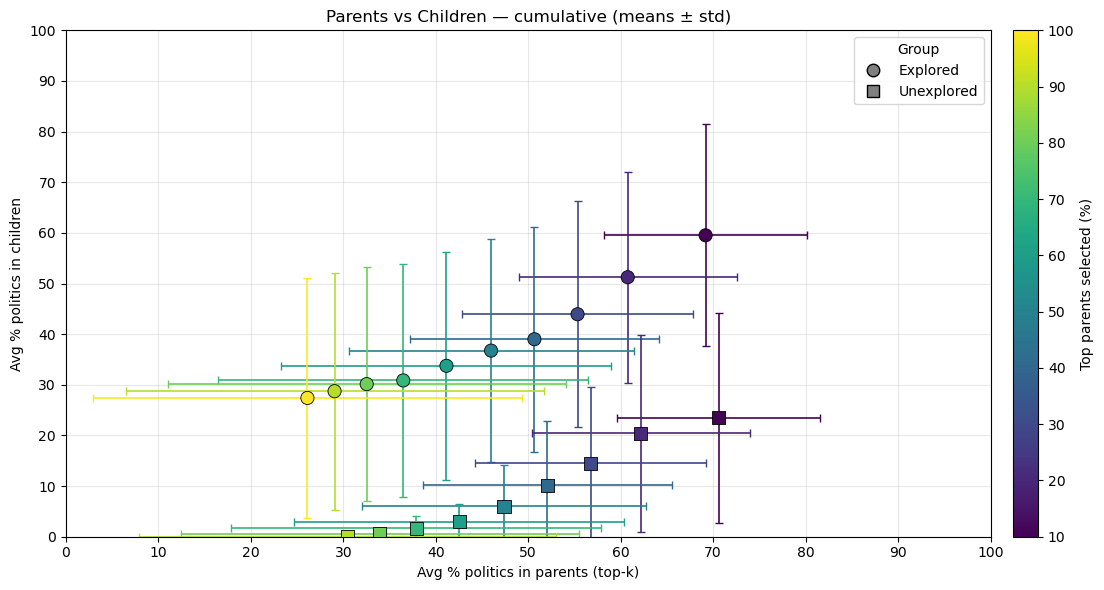

In [7]:
# ============================
# Setup e dati (già caricati da te)
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# ATTENZIONE: allineo i tipi numerici
summary_filtered0  = pd.read_csv(path_summary_filtered_0, compression="gzip")
summary_filtered1  = pd.read_csv(path_summary_filtered_1, compression="gzip")
summary_filtered = pd.concat([summary_filtered0, summary_filtered1], ignore_index=True)

# dedup sul vero ID di canale (stringa 'channel_...'), tieni l'ultima
summary_filtered = (summary_filtered
    .drop_duplicates(subset='channel_id', keep='last')
    .copy())

# cast numerici robusti
summary_filtered['pol_ratio_without_spam']  = pd.to_numeric(summary_filtered['pol_ratio_without_spam'], errors='coerce')
summary_filtered['pol_msgs']                = pd.to_numeric(summary_filtered['pol_msgs'], errors='coerce')
summary_filtered['total_msgs_without_spam'] = pd.to_numeric(summary_filtered['total_msgs_without_spam'], errors='coerce')

# edges grezzi
df_edges = pd.read_csv(path_df_edges, compression="gzip")

print(f"len summary_filtered: {len(summary_filtered)}")

# ============================
# 1) Parents ranking (eleggibili = con share non-NaN)
# ============================
parents_df = (summary_filtered[['channel_id', 'pol_ratio_without_spam']]
              .rename(columns={'channel_id':'parent_id',
                               'pol_ratio_without_spam':'parent_political_share'})
              .dropna(subset=['parent_id','parent_political_share'])
              .drop_duplicates(subset='parent_id')
              .copy())
parents_df['parent_political_share'] = parents_df['parent_political_share'].astype(float)

print(f"len parents_df: {len(parents_df)}")

# ============================
# 2) Edges solo verso genitori eleggibili
# ============================
parent_edges_df = (df_edges[df_edges['parent'].isin(parents_df['parent_id'])]
                   [['parent','type_and_id']]
                   .rename(columns={'parent':'parent_id','type_and_id':'child_id'})
                   .dropna()
                   .drop_duplicates()
                   .reset_index(drop=True))

print(f"len parent_edges_df: {len(parent_edges_df)}")

# ============================
# 3) Children stats (solo figli che hanno metriche)
# ============================
children_stats = (summary_filtered
                  .rename(columns={'channel_id':'child_id',
                                   'pol_msgs':'political_msgs',
                                   'total_msgs_without_spam':'total_msgs'})
                  [['child_id','political_msgs','total_msgs']])

children_df = (pd.merge(parent_edges_df[['child_id']].drop_duplicates(),
                        children_stats, on='child_id', how='left')
               .dropna(subset=['political_msgs','total_msgs'])
               .copy())
children_df['political_msgs'] = children_df['political_msgs'].astype(float)
children_df['total_msgs']     = children_df['total_msgs'].astype(float)
children_df = children_df[children_df['total_msgs'] > 0].reset_index(drop=True)

print(f"len children_df: {len(children_df)}")

# ============================
# Helpers
# ============================
def order_parents(parents_df: pd.DataFrame) -> np.ndarray:
    """Ordina i genitori per share politico desc e restituisce gli ID."""
    ordered = (parents_df
               .dropna(subset=['parent_political_share'])
               .sort_values('parent_political_share', ascending=False)['parent_id']
               .to_numpy())
    if len(ordered) == 0:
        raise ValueError("No parents available after sorting.")
    return ordered

def compute_scatter_stats_cumulative(
    parents_df, parent_edges_df, children_df,
    top_parent_percents=list(range(10, 101, 10))
) -> pd.DataFrame:
    """
    Tutto cumulativo:
      Explored = figli di TUTTI i top-k parents
      Unexplored = complemento
    """
    child_lookup = (children_df[['child_id','political_msgs','total_msgs']]
                    .drop_duplicates().set_index('child_id'))
    elig_children_in_edges = np.unique(parent_edges_df['child_id'].dropna().to_numpy())
    universe_children = np.intersect1d(elig_children_in_edges, child_lookup.index.to_numpy(), assume_unique=False)

    ordered = order_parents(parents_df)
    n_parents = len(ordered)
    share_map = parents_df.set_index('parent_id')['parent_political_share'].to_dict()

    rows = []
    for perc in sorted(top_parent_percents):
        k = max(1, int(np.ceil(n_parents * (perc / 100.0))))
        topk = ordered[:k]
        topk_shares = np.array([share_map[p] for p in topk if p in share_map], dtype=float)

        x_mean = float(np.nanmean(topk_shares))
        x_std  = float(np.nanstd(topk_shares, ddof=1)) if len(topk_shares) > 1 else 0.0

        sel = parent_edges_df['parent_id'].isin(set(topk))
        explored_children = np.unique(parent_edges_df.loc[sel, 'child_id'].dropna().to_numpy())
        explored_children = np.intersect1d(universe_children, explored_children, assume_unique=False)
        unexplored_children = np.setdiff1d(universe_children, explored_children, assume_unique=False)

        for group, arr in [('Explored', explored_children), ('Unexplored', unexplored_children)]:
            if arr.size == 0:
                rows.append({
                    'top_parents_pct': int(perc), 'Group': group,
                    'x_mean_pct': x_mean, 'x_std_pct': x_std,
                    'y_mean_pct': np.nan, 'y_std_pct': np.nan,
                    'n_parents': int(k), 'n_children': 0
                })
                continue

            sub = child_lookup.reindex(arr)[['political_msgs', 'total_msgs']].dropna()
            sub = sub[sub['total_msgs'] > 0]
            y_vals = (sub['political_msgs'] / sub['total_msgs']) * 100.0
            y_mean = float(y_vals.mean())
            y_std  = float(y_vals.std(ddof=1)) if len(y_vals) > 1 else 0.0

            rows.append({
                'top_parents_pct': int(perc), 'Group': group,
                'x_mean_pct': x_mean, 'x_std_pct': x_std,
                'y_mean_pct': y_mean, 'y_std_pct': y_std,
                'n_parents': int(k), 'n_children': int(len(y_vals))
            })

    return pd.DataFrame(rows)

def plot_scatter_cumulative(df_stats, title='', save_name=None):
    """Scatter con error bars, stile matplotlib uniforme."""
    if df_stats.empty:
        print("[WARN] df_stats è vuoto.")
        return

    vmin, vmax = df_stats['top_parents_pct'].min(), df_stats['top_parents_pct'].max()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    my_cmap = cm.get_cmap('viridis')

    group_offset = {'Explored': -0.7, 'Unexplored': +0.7}
    markers = {'Explored': 'o', 'Unexplored': 's'}

    df_plot = df_stats.copy()
    df_plot['color'] = df_plot['top_parents_pct'].apply(lambda p: my_cmap(norm(p)))

    fig, ax = plt.subplots(figsize=(12, 6))

    for g, sub in df_plot.groupby('Group'):
        x_plot = sub['x_mean_pct'] + group_offset[g]

        ax.scatter(
            x_plot, sub['y_mean_pct'],
            s=90, c=list(sub['color']),
            marker=markers[g],
            edgecolors='black', linewidths=0.6, zorder=3
        )

        for _, r in sub.iterrows():
            ax.errorbar(
                r['x_mean_pct'] + group_offset[g],
                r['y_mean_pct'],
                xerr=r['x_std_pct'],
                yerr=r['y_std_pct'],
                fmt='none',
                ecolor=r['color'],
                elinewidth=1.2,
                capsize=3,
                zorder=2
            )

    sm = cm.ScalarMappable(norm=norm, cmap=my_cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('Top parents selected (%)')

    ax.set_xticks(range(0, 101, 10))
    ax.set_yticks(range(0, 101, 10))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xlabel('Avg % politics in parents (top-k)')
    ax.set_ylabel('Avg % politics in children')
    ax.set_title(title or 'Parents vs Children — cumulative (means ± std)')
    ax.grid(True, alpha=0.3)

    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0], [0], marker='o', color='w', label='Explored',
               markerfacecolor='gray', markeredgecolor='black', markersize=9),
        Line2D([0], [0], marker='s', color='w', label='Unexplored',
               markerfacecolor='gray', markeredgecolor='black', markersize=9),
    ]
    ax.legend(handles=legend_elems, title='Group', loc='upper right', frameon=True)

    plt.tight_layout()
    if save_name:
        plt.savefig(f'{save_name}.png', dpi=150, bbox_inches='tight')
        plt.savefig(f'{save_name}.pdf', bbox_inches='tight')
    plt.show()

# ============================
# Run blocco 1
# ============================
fractions = list(range(10, 101, 10))

df_stats_cum = compute_scatter_stats_cumulative(
    parents_df, parent_edges_df, children_df,
    top_parent_percents=fractions
)

print(df_stats_cum.pivot(index='top_parents_pct', columns='Group', values='n_children').fillna(0).astype(int))

plot_scatter_cumulative(
    df_stats_cum,
    title='Parents vs Children — cumulative (means ± std)',
    save_name='std_graph_cumulative'
)

[INFO] parents=233, edges=24333, children(stats)=194
Group            Explored  Unexplored
top_parents_pct                      
10                     21         173
20                     29         150
30                     59         109
40                     61          78
50                     47          59
60                     35          40
70                     37          23
80                     17          18
90                     14           9
100                    13           0


/tmp/ipykernel_11165/1636416347.py:168: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_cmap = cm.get_cmap('viridis')


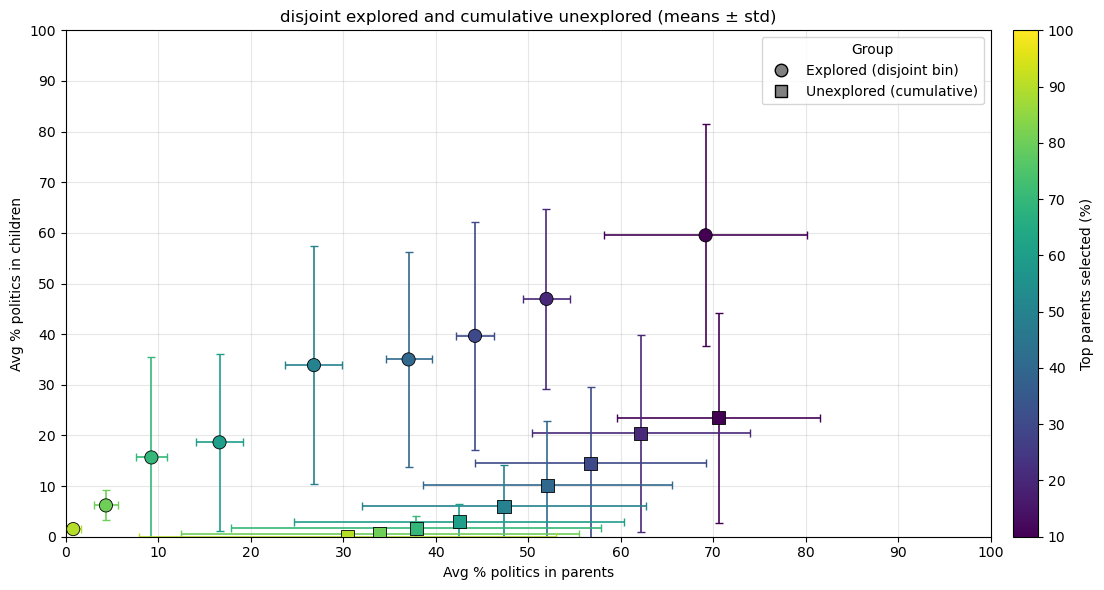

In [9]:
# ============================
# Imports
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# ============================
# dedup e cast robusti
# ============================
summary_filtered = (summary_filtered
    .drop_duplicates(subset='channel_id', keep='last')
    .copy())

summary_filtered['pol_ratio_without_spam']  = pd.to_numeric(summary_filtered['pol_ratio_without_spam'], errors='coerce')
summary_filtered['pol_msgs']                = pd.to_numeric(summary_filtered['pol_msgs'], errors='coerce')
summary_filtered['total_msgs_without_spam'] = pd.to_numeric(summary_filtered['total_msgs_without_spam'], errors='coerce')

# ----------------------------
# 1) Costruisco le 3 tabelle base
# ----------------------------
parents_df = (summary_filtered[['channel_id', 'pol_ratio_without_spam']]
              .rename(columns={'channel_id':'parent_id',
                               'pol_ratio_without_spam':'parent_political_share'})
              .dropna(subset=['parent_id','parent_political_share'])
              .drop_duplicates(subset='parent_id')
              .copy())
parents_df['parent_political_share'] = parents_df['parent_political_share'].astype(float)

parent_edges_df = (df_edges[df_edges['parent'].isin(parents_df['parent_id'])]
                   [['parent','type_and_id']]
                   .rename(columns={'parent':'parent_id','type_and_id':'child_id'})
                   .dropna()
                   .drop_duplicates()
                   .reset_index(drop=True))

children_stats = (summary_filtered
                  .rename(columns={'channel_id':'child_id',
                                   'pol_msgs':'political_msgs',
                                   'total_msgs_without_spam':'total_msgs'})
                  [['child_id','political_msgs','total_msgs']])

children_df = (pd.merge(parent_edges_df[['child_id']].drop_duplicates(),
                        children_stats, on='child_id', how='left')
               .dropna(subset=['political_msgs','total_msgs'])
               .copy())
children_df['political_msgs'] = children_df['political_msgs'].astype(float)
children_df['total_msgs']     = children_df['total_msgs'].astype(float)
children_df = children_df[children_df['total_msgs'] > 0].reset_index(drop=True)

print(f"[INFO] parents={len(parents_df)}, edges={len(parent_edges_df)}, children(stats)={len(children_df)}")

# ----------------------------
# 2) Helpers
# ----------------------------
def order_parents(parents_df: pd.DataFrame) -> np.ndarray:
    """Ordina i genitori per share politica desc e restituisce gli ID."""
    ordered = (parents_df
               .dropna(subset=['parent_political_share'])
               .sort_values('parent_political_share', ascending=False)['parent_id']
               .to_numpy())
    if len(ordered) == 0:
        raise ValueError("No parents available after sorting.")
    return ordered

def compute_scatter_stats_disjoint(
    parents_df, parent_edges_df, children_df,
    top_parent_percents=list(range(10, 101, 10))
) -> pd.DataFrame:
    """
    Explored = bin disgiunto (prev_pct, pct] — NON cumulativo
    Unexplored = complemento dei top-k cumulativi — cumulativo
    """
    child_lookup = (children_df[['child_id','political_msgs','total_msgs']]
                    .drop_duplicates().set_index('child_id'))
    elig_children_in_edges = np.unique(parent_edges_df['child_id'].dropna().to_numpy())
    universe_children = np.intersect1d(elig_children_in_edges, child_lookup.index.to_numpy(), assume_unique=False)

    ordered = order_parents(parents_df)
    n_parents = len(ordered)
    share_map = parents_df.set_index('parent_id')['parent_political_share'].to_dict()

    rows = []
    prev_k = 0
    for perc in sorted(top_parent_percents):
        k = max(1, int(np.ceil(n_parents * (perc / 100.0))))
        bin_start = prev_k
        bin_end = k
        if bin_end <= bin_start:
            bin_end = min(n_parents, bin_start + 1)

        bin_parents  = ordered[bin_start:bin_end]
        topk_parents = ordered[:k]

        # X per Explored = share dei parent nel solo BIN
        bin_shares  = np.array([share_map[p] for p in bin_parents if p in share_map], dtype=float)
        x_mean_expl = float(np.nanmean(bin_shares)) if bin_shares.size > 0 else np.nan
        x_std_expl  = float(np.nanstd(bin_shares, ddof=1)) if bin_shares.size > 1 else 0.0

        # X per Unexplored = share dei TOP-K cumulativi
        topk_shares = np.array([share_map[p] for p in topk_parents if p in share_map], dtype=float)
        x_mean_unex = float(np.nanmean(topk_shares)) if topk_shares.size > 0 else np.nan
        x_std_unex  = float(np.nanstd(topk_shares, ddof=1)) if topk_shares.size > 1 else 0.0

        # Y Explored = figli collegati al BIN (non-cum)
        sel_bin = parent_edges_df['parent_id'].isin(set(bin_parents))
        explored_children_bin = np.unique(parent_edges_df.loc[sel_bin, 'child_id'].dropna().to_numpy())
        explored_children_bin = np.intersect1d(universe_children, explored_children_bin, assume_unique=False)

        if explored_children_bin.size:
            sub_e = child_lookup.reindex(explored_children_bin)[['political_msgs','total_msgs']].dropna()
            sub_e = sub_e[sub_e['total_msgs'] > 0]
            y_vals_e = (sub_e['political_msgs'] / sub_e['total_msgs']) * 100.0
            rows.append({
                'top_parents_pct': int(perc), 'Group': 'Explored',
                'x_mean_pct': x_mean_expl, 'x_std_pct': x_std_expl,
                'y_mean_pct': float(y_vals_e.mean()),
                'y_std_pct': float(y_vals_e.std(ddof=1)) if len(y_vals_e) > 1 else 0.0,
                'n_parents': int(len(bin_parents)), 'n_children': int(len(y_vals_e))
            })
        else:
            rows.append({
                'top_parents_pct': int(perc), 'Group': 'Explored',
                'x_mean_pct': x_mean_expl, 'x_std_pct': x_std_expl,
                'y_mean_pct': np.nan, 'y_std_pct': np.nan,
                'n_parents': int(len(bin_parents)), 'n_children': 0
            })

        # Y Unexplored = COMPLEMENTO dei top-k (cumulativo)
        sel_cum = parent_edges_df['parent_id'].isin(set(topk_parents))
        explored_children_cum = np.unique(parent_edges_df.loc[sel_cum, 'child_id'].dropna().to_numpy())
        explored_children_cum = np.intersect1d(universe_children, explored_children_cum, assume_unique=False)
        unexplored_cum = np.setdiff1d(universe_children, explored_children_cum, assume_unique=False)

        if unexplored_cum.size:
            sub_u = child_lookup.reindex(unexplored_cum)[['political_msgs','total_msgs']].dropna()
            sub_u = sub_u[sub_u['total_msgs'] > 0]
            y_vals_u = (sub_u['political_msgs'] / sub_u['total_msgs']) * 100.0
            rows.append({
                'top_parents_pct': int(perc), 'Group': 'Unexplored',
                'x_mean_pct': x_mean_unex, 'x_std_pct': x_std_unex,
                'y_mean_pct': float(y_vals_u.mean()),
                'y_std_pct': float(y_vals_u.std(ddof=1)) if len(y_vals_u) > 1 else 0.0,
                'n_parents': int(k), 'n_children': int(len(y_vals_u))
            })
        else:
            rows.append({
                'top_parents_pct': int(perc), 'Group': 'Unexplored',
                'x_mean_pct': x_mean_unex, 'x_std_pct': x_std_unex,
                'y_mean_pct': np.nan, 'y_std_pct': np.nan,
                'n_parents': int(k), 'n_children': 0
            })

        prev_k = k

    return pd.DataFrame(rows)

def plot_scatter_disjoint(df_stats, title='', save_name=None):
    """Scatter con error bars, Explored a bin disgiunti."""
    if df_stats.empty:
        print("[WARN] df_stats è vuoto.")
        return

    vmin, vmax = df_stats['top_parents_pct'].min(), df_stats['top_parents_pct'].max()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    my_cmap = cm.get_cmap('viridis')

    group_offset = {'Explored': -0.7, 'Unexplored': +0.7}
    markers = {'Explored': 'o', 'Unexplored': 's'}

    df_plot = df_stats.copy()
    df_plot['color'] = df_plot['top_parents_pct'].apply(lambda p: my_cmap(norm(p)))

    fig, ax = plt.subplots(figsize=(12, 6))

    for g, sub in df_plot.groupby('Group'):
        x_plot = sub['x_mean_pct'] + group_offset[g]

        ax.scatter(
            x_plot, sub['y_mean_pct'],
            s=90, c=list(sub['color']),
            marker=markers[g],
            edgecolors='black', linewidths=0.6, zorder=3
        )

        for _, r in sub.iterrows():
            ax.errorbar(
                r['x_mean_pct'] + group_offset[g],
                r['y_mean_pct'],
                xerr=r['x_std_pct'],
                yerr=r['y_std_pct'],
                fmt='none',
                ecolor=r['color'],
                elinewidth=1.2,
                capsize=3,
                zorder=2
            )

    sm = cm.ScalarMappable(norm=norm, cmap=my_cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('Top parents selected (%)')

    ax.set_xticks(range(0, 101, 10))
    ax.set_yticks(range(0, 101, 10))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xlabel('Avg % politics in parents')
    ax.set_ylabel('Avg % politics in children')
    ax.set_title(title or 'Parents vs Children — disjoint explored vs cumulative unexplored (means ± std)')
    ax.grid(True, alpha=0.3)

    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0], [0], marker='o', color='w', label='Explored (disjoint bin)',
               markerfacecolor='gray', markeredgecolor='black', markersize=9),
        Line2D([0], [0], marker='s', color='w', label='Unexplored (cumulative)',
               markerfacecolor='gray', markeredgecolor='black', markersize=9),
    ]
    ax.legend(handles=legend_elems, title='Group', loc='upper right', frameon=True)

    plt.tight_layout()
    if save_name:
        plt.savefig(f'{save_name}.png', dpi=150, bbox_inches='tight')
        plt.savefig(f'{save_name}.pdf', bbox_inches='tight')
    plt.show()

# ----------------------------
# 3) Run blocco 2
# ----------------------------
fractions = list(range(10, 101, 10))

df_stats_disj = compute_scatter_stats_disjoint(
    parents_df, parent_edges_df, children_df,
    top_parent_percents=fractions
)

print(df_stats_disj.pivot(index='top_parents_pct', columns='Group', values='n_children').fillna(0).astype(int))

plot_scatter_disjoint(
    df_stats_disj,
    title='disjoint explored and cumulative unexplored (means ± std)',
    save_name='std_graph_disjoint'
)

len summary_filtered: 233
len parents_df: 233
len parent_edges_df: 24333
len children_df: 194
Group            Explored  Unexplored
top_parents_pct                      
10                     21         173
20                     30         164
30                     59         135
40                     64         130
50                     48         146
60                     36         158
70                     38         156
80                     17         177
90                     15         179
100                    14         180

    top_parents_pct       Group  x_mean_pct  y_mean_pct
0                10    Explored   69.879206   59.520349
1                10  Unexplored   69.879206   23.505557
2                20    Explored   52.888165   47.325175
3                20  Unexplored   52.888165   23.759960
4                30    Explored   45.103581   39.665539
5                30  Unexplored   45.103581   22.045347
6                40    Explored   37.916521   35.094510
7

/tmp/ipykernel_11165/3195786211.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_cmap = cm.get_cmap('viridis')


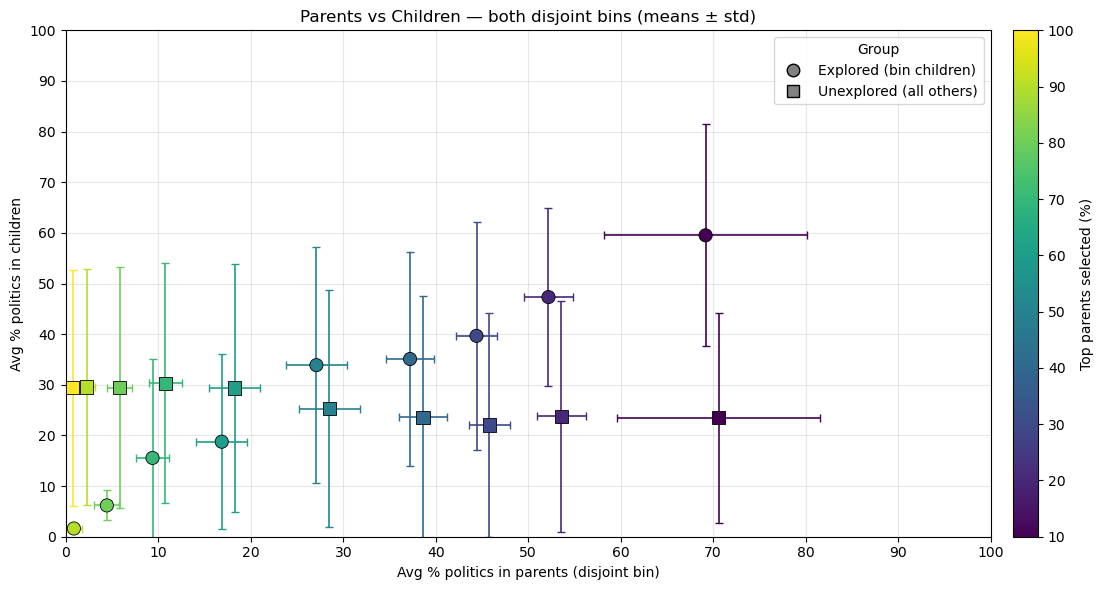

In [15]:
# ============================
# Setup e dati
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Caricamento dati
summary_filtered0  = pd.read_csv(path_summary_filtered_0, compression="gzip")
summary_filtered1  = pd.read_csv(path_summary_filtered_1, compression="gzip")
summary_filtered = pd.concat([summary_filtered0, summary_filtered1], ignore_index=True)

summary_filtered = (summary_filtered
    .drop_duplicates(subset='channel_id', keep='last')
    .copy())

summary_filtered['pol_ratio_without_spam']  = pd.to_numeric(summary_filtered['pol_ratio_without_spam'], errors='coerce')
summary_filtered['pol_msgs']                = pd.to_numeric(summary_filtered['pol_msgs'], errors='coerce')
summary_filtered['total_msgs_without_spam'] = pd.to_numeric(summary_filtered['total_msgs_without_spam'], errors='coerce')

df_edges = pd.read_csv(path_df_edges, compression="gzip")

print(f"len summary_filtered: {len(summary_filtered)}")

# ============================
# 1) Parents ranking
# ============================
parents_df = (summary_filtered[['channel_id', 'pol_ratio_without_spam']]
              .rename(columns={'channel_id':'parent_id',
                               'pol_ratio_without_spam':'parent_political_share'})
              .dropna(subset=['parent_id','parent_political_share'])
              .drop_duplicates(subset='parent_id')
              .copy())
parents_df['parent_political_share'] = parents_df['parent_political_share'].astype(float)

print(f"len parents_df: {len(parents_df)}")

# ============================
# 2) Edges solo verso genitori eleggibili
# ============================
parent_edges_df = (df_edges[df_edges['parent'].isin(parents_df['parent_id'])]
                   [['parent','type_and_id']]
                   .rename(columns={'parent':'parent_id','type_and_id':'child_id'})
                   .dropna()
                   .drop_duplicates()
                   .reset_index(drop=True))

print(f"len parent_edges_df: {len(parent_edges_df)}")

# ============================
# 3) Children stats
# ============================
children_stats = (summary_filtered
                  .rename(columns={'channel_id':'child_id',
                                   'pol_msgs':'political_msgs',
                                   'total_msgs_without_spam':'total_msgs'})
                  [['child_id','political_msgs','total_msgs']])

children_df = (pd.merge(parent_edges_df[['child_id']].drop_duplicates(),
                        children_stats, on='child_id', how='left')
               .dropna(subset=['political_msgs','total_msgs'])
               .copy())
children_df['political_msgs'] = children_df['political_msgs'].astype(float)
children_df['total_msgs']     = children_df['total_msgs'].astype(float)
children_df = children_df[children_df['total_msgs'] > 0].reset_index(drop=True)

print(f"len children_df: {len(children_df)}")

# ============================
# Helpers
# ============================
def order_parents(parents_df: pd.DataFrame) -> np.ndarray:
    """Ordina i genitori per share politica desc e restituisce gli ID."""
    ordered = (parents_df
               .dropna(subset=['parent_political_share'])
               .sort_values('parent_political_share', ascending=False)['parent_id']
               .to_numpy())
    if len(ordered) == 0:
        raise ValueError("No parents available after sorting.")
    return ordered

# ============================
# 4) Compute: ENTRAMBI disjoint bin
#    Per ogni bin (prev_pct, perc]:
#      - Explored = figli collegati ai parents del bin
#      - Unexplored = universo figli - figli collegati ai parents del bin
#      - X = media political ratio dei parents nel bin (stessa per entrambi)
# ============================
def compute_scatter_both_disjoint(
    parents_df, parent_edges_df, children_df,
    top_parent_percents=list(range(10, 101, 10))
) -> pd.DataFrame:
    """
    Entrambi i gruppi usano bin disgiunti:
      Explored = figli collegati ai parents nel bin (prev_pct, perc]
      Unexplored = universo figli - figli collegati a quei parents
      X = media political ratio dei parents nel bin (uguale per entrambi)
    """
    child_lookup = (children_df[['child_id','political_msgs','total_msgs']]
                    .drop_duplicates().set_index('child_id'))
    elig_children_in_edges = np.unique(parent_edges_df['child_id'].dropna().to_numpy())
    universe_children = np.intersect1d(elig_children_in_edges, child_lookup.index.to_numpy(), assume_unique=False)

    ordered = order_parents(parents_df)
    n_parents = len(ordered)
    share_map = parents_df.set_index('parent_id')['parent_political_share'].to_dict()

    rows = []
    prev_pct = 0
    for perc in sorted(top_parent_percents):
        # Bin disgiunto (prev_pct, perc]
        start = int(np.floor(n_parents * (prev_pct / 100.0)))
        end   = int(np.ceil(n_parents * (perc / 100.0)))
        if end <= start:
            end = min(n_parents, start + 1)
        bin_parents = ordered[start:end]

        # X = media ratio dei parents nel bin (uguale per Explored e Unexplored)
        bin_shares = np.array([share_map[p] for p in bin_parents if p in share_map], dtype=float)
        x_mean = float(np.nanmean(bin_shares)) if bin_shares.size > 0 else np.nan
        x_std  = float(np.nanstd(bin_shares, ddof=1)) if bin_shares.size > 1 else 0.0

        # Figli collegati ai parents del bin
        sel_bin = parent_edges_df['parent_id'].isin(set(bin_parents))
        bin_children = np.unique(parent_edges_df.loc[sel_bin, 'child_id'].dropna().to_numpy())
        bin_children = np.intersect1d(universe_children, bin_children, assume_unique=False)

        # Unexplored = universo - figli del bin
        not_bin_children = np.setdiff1d(universe_children, bin_children, assume_unique=False)

        # --- Explored ---
        if bin_children.size:
            sub_e = child_lookup.reindex(bin_children)[['political_msgs','total_msgs']].dropna()
            sub_e = sub_e[sub_e['total_msgs'] > 0]
            y_vals_e = (sub_e['political_msgs'] / sub_e['total_msgs']) * 100.0
            rows.append({
                'top_parents_pct': int(perc), 'Group': 'Explored',
                'x_mean_pct': x_mean, 'x_std_pct': x_std,
                'y_mean_pct': float(y_vals_e.mean()),
                'y_std_pct': float(y_vals_e.std(ddof=1)) if len(y_vals_e) > 1 else 0.0,
                'n_parents': int(len(bin_parents)), 'n_children': int(len(y_vals_e))
            })
        else:
            rows.append({
                'top_parents_pct': int(perc), 'Group': 'Explored',
                'x_mean_pct': x_mean, 'x_std_pct': x_std,
                'y_mean_pct': np.nan, 'y_std_pct': np.nan,
                'n_parents': int(len(bin_parents)), 'n_children': 0
            })

        # --- Unexplored ---
        if not_bin_children.size:
            sub_u = child_lookup.reindex(not_bin_children)[['political_msgs','total_msgs']].dropna()
            sub_u = sub_u[sub_u['total_msgs'] > 0]
            y_vals_u = (sub_u['political_msgs'] / sub_u['total_msgs']) * 100.0
            rows.append({
                'top_parents_pct': int(perc), 'Group': 'Unexplored',
                'x_mean_pct': x_mean, 'x_std_pct': x_std,
                'y_mean_pct': float(y_vals_u.mean()),
                'y_std_pct': float(y_vals_u.std(ddof=1)) if len(y_vals_u) > 1 else 0.0,
                'n_parents': int(len(bin_parents)), 'n_children': int(len(y_vals_u))
            })
        else:
            rows.append({
                'top_parents_pct': int(perc), 'Group': 'Unexplored',
                'x_mean_pct': x_mean, 'x_std_pct': x_std,
                'y_mean_pct': np.nan, 'y_std_pct': np.nan,
                'n_parents': int(len(bin_parents)), 'n_children': 0
            })

        prev_pct = perc

    return pd.DataFrame(rows)

# ============================
# 5) Plot
# ============================
def plot_scatter_both_disjoint(df_stats, title='', save_name=None):
    """Scatter con error bars, entrambi i gruppi a bin disgiunti."""
    if df_stats.empty:
        print("[WARN] df_stats è vuoto.")
        return

    vmin, vmax = df_stats['top_parents_pct'].min(), df_stats['top_parents_pct'].max()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    my_cmap = cm.get_cmap('viridis')

    group_offset = {'Explored': -0.7, 'Unexplored': +0.7}
    markers = {'Explored': 'o', 'Unexplored': 's'}

    df_plot = df_stats.copy()
    df_plot['color'] = df_plot['top_parents_pct'].apply(lambda p: my_cmap(norm(p)))

    fig, ax = plt.subplots(figsize=(12, 6))

    for g, sub in df_plot.groupby('Group'):
        x_plot = sub['x_mean_pct'] + group_offset[g]

        ax.scatter(
            x_plot, sub['y_mean_pct'],
            s=90, c=list(sub['color']),
            marker=markers[g],
            edgecolors='black', linewidths=0.6, zorder=3
        )

        for _, r in sub.iterrows():
            ax.errorbar(
                r['x_mean_pct'] + group_offset[g],
                r['y_mean_pct'],
                xerr=r['x_std_pct'],
                yerr=r['y_std_pct'],
                fmt='none',
                ecolor=r['color'],
                elinewidth=1.2,
                capsize=3,
                zorder=2
            )

    sm = cm.ScalarMappable(norm=norm, cmap=my_cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('Top parents selected (%)')

    ax.set_xticks(range(0, 101, 10))
    ax.set_yticks(range(0, 101, 10))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xlabel('Avg % politics in parents (disjoint bin)')
    ax.set_ylabel('Avg % politics in children')
    ax.set_title(title or 'Parents vs Children — both disjoint bins (means ± std)')
    ax.grid(True, alpha=0.3)

    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0], [0], marker='o', color='w', label='Explored (bin children)',
               markerfacecolor='gray', markeredgecolor='black', markersize=9),
        Line2D([0], [0], marker='s', color='w', label='Unexplored (all others)',
               markerfacecolor='gray', markeredgecolor='black', markersize=9),
    ]
    ax.legend(handles=legend_elems, title='Group', loc='upper right', frameon=True)

    plt.tight_layout()
    if save_name:
        plt.savefig(f'{save_name}.png', dpi=150, bbox_inches='tight')
        plt.savefig(f'{save_name}.pdf', bbox_inches='tight')
    plt.show()

# ============================
# 6) Run
# ============================
fractions = list(range(10, 101, 10))

df_stats_both_disj = compute_scatter_both_disjoint(
    parents_df, parent_edges_df, children_df,
    top_parent_percents=fractions
)

print(df_stats_both_disj.pivot(index='top_parents_pct', columns='Group', values='n_children').fillna(0).astype(int))
print()
print(df_stats_both_disj[['top_parents_pct', 'Group', 'x_mean_pct', 'y_mean_pct']].to_string())

plot_scatter_both_disjoint(
    df_stats_both_disj,
    title='Parents vs Children — both disjoint bins (means ± std)',
    save_name='std_graph_both_disjoint'
)

[INFO] parents=233, edges=24333, children(stats)=194
   top_parents_pct  n_parents  n_children  x_mean_pct  y_mean_pct
0               10         24         173       69.88       23.51
1               20         47         150       61.46       20.41
2               30         70         109       56.03       14.51
3               40         94          78       51.37       10.16
4               50        117          59       46.68        6.01
5               60        140          40       41.86        2.96
6               70        164          23       37.18        1.68
7               80        187          18       33.23        0.63
8               90        210           9       29.75        0.03
9              100        233           0       26.82         NaN


/tmp/ipykernel_11165/1722812230.py:137: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_cmap = cm.get_cmap('viridis')


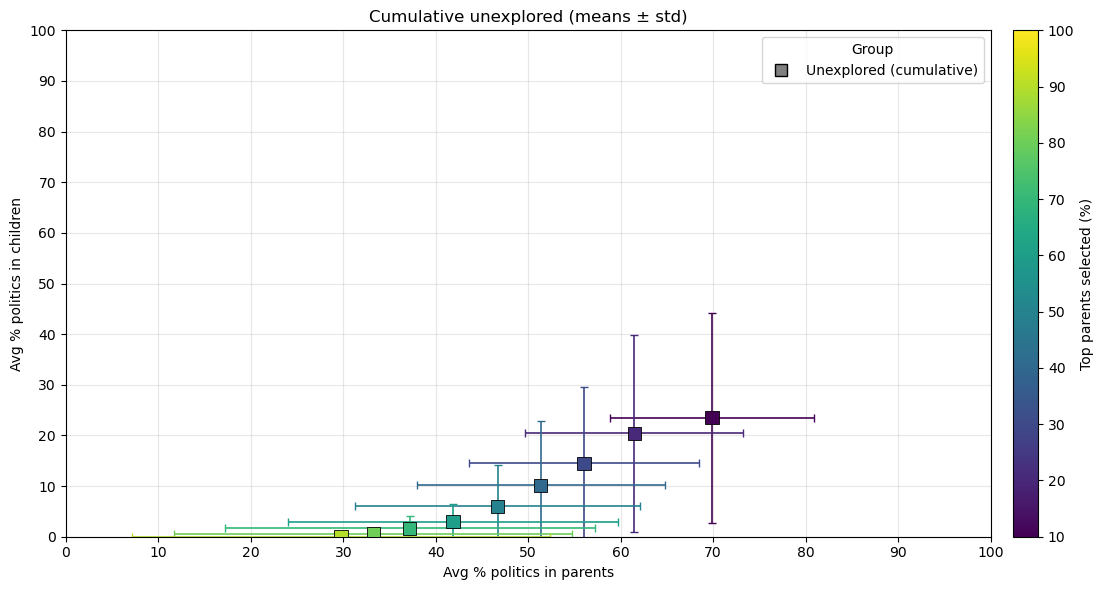

In [16]:
# ============================
# Imports
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# ============================
# dedup e cast robusti
# ============================
summary_filtered = (summary_filtered
    .drop_duplicates(subset='channel_id', keep='last')
    .copy())

summary_filtered['pol_ratio_without_spam']  = pd.to_numeric(summary_filtered['pol_ratio_without_spam'], errors='coerce')
summary_filtered['pol_msgs']                = pd.to_numeric(summary_filtered['pol_msgs'], errors='coerce')
summary_filtered['total_msgs_without_spam'] = pd.to_numeric(summary_filtered['total_msgs_without_spam'], errors='coerce')

# ============================
# 1) Costruisco le 3 tabelle base
# ============================
parents_df = (summary_filtered[['channel_id', 'pol_ratio_without_spam']]
              .rename(columns={'channel_id':'parent_id',
                               'pol_ratio_without_spam':'parent_political_share'})
              .dropna(subset=['parent_id','parent_political_share'])
              .drop_duplicates(subset='parent_id')
              .copy())
parents_df['parent_political_share'] = parents_df['parent_political_share'].astype(float)

parent_edges_df = (df_edges[df_edges['parent'].isin(parents_df['parent_id'])]
                   [['parent','type_and_id']]
                   .rename(columns={'parent':'parent_id','type_and_id':'child_id'})
                   .dropna()
                   .drop_duplicates()
                   .reset_index(drop=True))

children_stats = (summary_filtered
                  .rename(columns={'channel_id':'child_id',
                                   'pol_msgs':'political_msgs',
                                   'total_msgs_without_spam':'total_msgs'})
                  [['child_id','political_msgs','total_msgs']])

children_df = (pd.merge(parent_edges_df[['child_id']].drop_duplicates(),
                        children_stats, on='child_id', how='left')
               .dropna(subset=['political_msgs','total_msgs'])
               .copy())
children_df['political_msgs'] = children_df['political_msgs'].astype(float)
children_df['total_msgs']     = children_df['total_msgs'].astype(float)
children_df = children_df[children_df['total_msgs'] > 0].reset_index(drop=True)

print(f"[INFO] parents={len(parents_df)}, edges={len(parent_edges_df)}, children(stats)={len(children_df)}")

# ============================
# 2) Helpers
# ============================
def order_parents(parents_df: pd.DataFrame) -> np.ndarray:
    """Ordina i genitori per share politica desc e restituisce gli ID."""
    ordered = (parents_df
               .dropna(subset=['parent_political_share'])
               .sort_values('parent_political_share', ascending=False)['parent_id']
               .to_numpy())
    if len(ordered) == 0:
        raise ValueError("No parents available after sorting.")
    return ordered

def compute_scatter_stats_unexplored(
    parents_df, parent_edges_df, children_df,
    top_parent_percents=list(range(10, 101, 10))
) -> pd.DataFrame:
    """
    Unexplored = complemento dei top-k cumulativi (solo cumulativo)
    """
    child_lookup = (children_df[['child_id','political_msgs','total_msgs']]
                    .drop_duplicates().set_index('child_id'))
    elig_children_in_edges = np.unique(parent_edges_df['child_id'].dropna().to_numpy())
    universe_children = np.intersect1d(elig_children_in_edges, child_lookup.index.to_numpy(), assume_unique=False)

    ordered = order_parents(parents_df)
    n_parents = len(ordered)
    share_map = parents_df.set_index('parent_id')['parent_political_share'].to_dict()

    rows = []
    for perc in sorted(top_parent_percents):
        k = max(1, int(np.ceil(n_parents * (perc / 100.0))))
        topk_parents = ordered[:k]

        # X per Unexplored = share dei TOP-K cumulativi
        topk_shares = np.array([share_map[p] for p in topk_parents if p in share_map], dtype=float)
        x_mean_unex = float(np.nanmean(topk_shares)) if topk_shares.size > 0 else np.nan
        x_std_unex  = float(np.nanstd(topk_shares, ddof=1)) if topk_shares.size > 1 else 0.0

        # Y Unexplored = COMPLEMENTO dei top-k (cumulativo)
        sel_cum = parent_edges_df['parent_id'].isin(set(topk_parents))
        explored_children_cum = np.unique(parent_edges_df.loc[sel_cum, 'child_id'].dropna().to_numpy())
        explored_children_cum = np.intersect1d(universe_children, explored_children_cum, assume_unique=False)
        unexplored_cum = np.setdiff1d(universe_children, explored_children_cum, assume_unique=False)

        if unexplored_cum.size:
            sub_u = child_lookup.reindex(unexplored_cum)[['political_msgs','total_msgs']].dropna()
            sub_u = sub_u[sub_u['total_msgs'] > 0]
            if not sub_u.empty:
                y_vals_u = (sub_u['political_msgs'] / sub_u['total_msgs']) * 100.0
                rows.append({
                    'top_parents_pct': int(perc), 'Group': 'Unexplored',
                    'x_mean_pct': x_mean_unex, 'x_std_pct': x_std_unex,
                    'y_mean_pct': float(y_vals_u.mean()),
                    'y_std_pct': float(y_vals_u.std(ddof=1)) if len(y_vals_u) > 1 else 0.0,
                    'n_parents': int(k), 'n_children': int(len(y_vals_u))
                })
            else:
                rows.append({
                    'top_parents_pct': int(perc), 'Group': 'Unexplored',
                    'x_mean_pct': x_mean_unex, 'x_std_pct': x_std_unex,
                    'y_mean_pct': np.nan, 'y_std_pct': np.nan,
                    'n_parents': int(k), 'n_children': 0
                })
        else:
            rows.append({
                'top_parents_pct': int(perc), 'Group': 'Unexplored',
                'x_mean_pct': x_mean_unex, 'x_std_pct': x_std_unex,
                'y_mean_pct': np.nan, 'y_std_pct': np.nan,
                'n_parents': int(k), 'n_children': 0
            })

    return pd.DataFrame(rows)

def plot_scatter_unexplored(df_stats, title='', save_name=None):
    """Scatter con error bars, solo cumulativo (Unexplored)."""
    if df_stats.empty:
        print("[WARN] df_stats è vuoto.")
        return

    vmin, vmax = df_stats['top_parents_pct'].min(), df_stats['top_parents_pct'].max()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    my_cmap = cm.get_cmap('viridis')

    df_plot = df_stats.copy()
    df_plot['color'] = df_plot['top_parents_pct'].apply(lambda p: my_cmap(norm(p)))

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.scatter(
        df_plot['x_mean_pct'], df_plot['y_mean_pct'],
        s=90, c=list(df_plot['color']),
        marker='s',
        edgecolors='black', linewidths=0.6, zorder=3
    )

    for _, r in df_plot.iterrows():
        ax.errorbar(
            r['x_mean_pct'],
            r['y_mean_pct'],
            xerr=r['x_std_pct'],
            yerr=r['y_std_pct'],
            fmt='none',
            ecolor=r['color'],
            elinewidth=1.2,
            capsize=3,
            zorder=2
        )

    sm = cm.ScalarMappable(norm=norm, cmap=my_cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('Top parents selected (%)')

    ax.set_xticks(range(0, 101, 10))
    ax.set_yticks(range(0, 101, 10))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xlabel('Avg % politics in parents')
    ax.set_ylabel('Avg % politics in children')
    ax.set_title(title or 'Parents vs Children — cumulative unexplored (means ± std)')
    ax.grid(True, alpha=0.3)

    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0], [0], marker='s', color='w', label='Unexplored (cumulative)',
               markerfacecolor='gray', markeredgecolor='black', markersize=9),
    ]
    ax.legend(handles=legend_elems, title='Group', loc='upper right', frameon=True)

    plt.tight_layout()
    if save_name:
        plt.savefig(f'{save_name}.png', dpi=150, bbox_inches='tight')
        plt.savefig(f'{save_name}.pdf', bbox_inches='tight')
    plt.show()

# ============================
# 3) Run blocco 2
# ============================
fractions = list(range(10, 101, 10))

df_stats_unex = compute_scatter_stats_unexplored(
    parents_df, parent_edges_df, children_df,
    top_parent_percents=fractions
)

print(df_stats_unex[['top_parents_pct', 'n_parents', 'n_children', 'x_mean_pct', 'y_mean_pct']].round(2))

plot_scatter_unexplored(
    df_stats_unex,
    title='Cumulative unexplored (means ± std)',
    save_name='std_graph_unexplored'
)